<a href="https://colab.research.google.com/github/macsrc/mac-handson-ml3/blob/handson-ml-241025/ch15_explore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import sys
assert sys.version_info >= (3,7)

In [23]:
from packaging import version
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

In [24]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [63]:
from pathlib import Path

IMAGE_PATH = Path()/ "images"/ "rnn"
IMAGE_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
  path= IMAGE_PATH/ f"{fig_id}.{fig_extension}"
  if tight_layout:
    plt.tight_layout
  plt.savefig(path, dpi=resolution)

In [26]:
if not tf.config.list_physical_devices('GPU'):
  print("No GPU was detected. Neural nets can be very slow without a GPU.")
  if "google.colab" in sys.modules:
    print("Go to Runtime > Change runtime and select a GPU hardware accelerator")
  if "kaggle_secrets" in sys.modules:
    print("Go to Settings > Accelerator and select GPU.")

No GPU was detected. Neural nets can be very slow without a GPU.
Go to Runtime > Change runtime and select a GPU hardware accelerator


# Basic RNNs

In [27]:
import tarfile
from pathlib import Path

filepath = tf.keras.utils.get_file(
    "ridership.tgz",
    "https://github.com/ageron/data/raw/main/ridership.tgz",
    cache_dir="./datasets", # Changed cache_dir to ./datasets
    # extracted=True # Removed this argument as it causes a TypeError
)

# Manually extract the tar.gz file
# filepath will be something like './datasets/ridership.tgz'
with tarfile.open(filepath, "r:gz") as tar:
    tar.extractall(path=Path(filepath).parent) # Extracts to the same directory as the tgz file, i.e., './datasets'

# ridership_path will be './datasets/ridership' after extraction
ridership_path = Path(filepath).with_name("ridership")

/tmp/ipython-input-2906737596.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=Path(filepath).parent) # Extracts to the same directory as the tgz file, i.e., './datasets'


In [28]:
import pandas as pd
from pathlib import Path

path = ridership_path / "CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [29]:
import pandas as pd
from pathlib import Path

path = ridership_path / "CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]  # shorter names
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)  # no need for total, it's just bus + rail
df = df.drop_duplicates()  # remove duplicated months (2011-10 and 2014-07)

In [30]:
import pandas as pd
from pathlib import Path

# path - "CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
path = ridership_path/"CTA_-_Ridership_-_Daily_Boarding_Totals.csv"
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"]
df = df.sort_values("date").set_index("date")
df = df.drop("total", axis=1)
df = df.drop_duplicates()


In [31]:
df.head()

,day_type,bus,rail
date,,,
2001-01-01,U,297192,126455
2001-01-02,W,780827,501952
2001-01-03,W,824923,536432
2001-01-04,W,870021,550011
2001-01-05,W,890426,557917


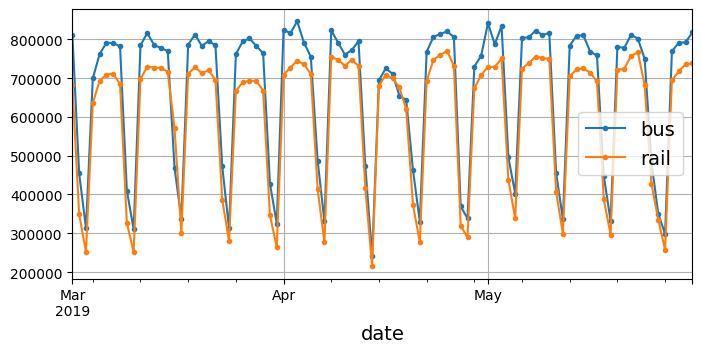

In [32]:
import matplotlib.pyplot as plt

df["2019-03":"2019-05"].plot(grid=True, marker=".", figsize=(8,3.5))
plt.show()

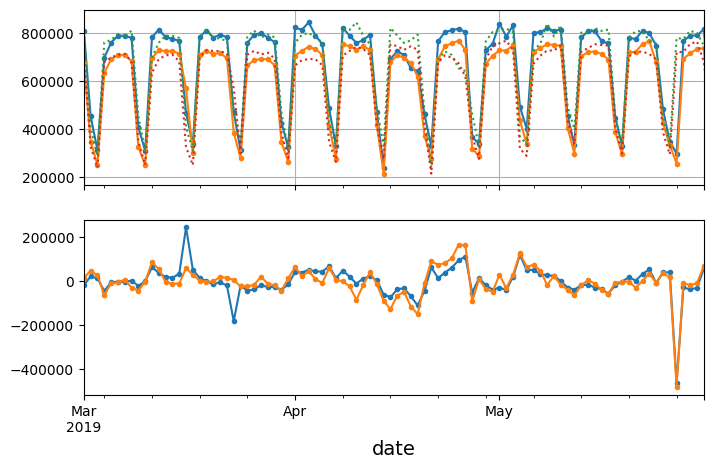

In [38]:
diff_7 = df[["rail", "bus"]].diff(7)["2019-3":"2019-05"]

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8,5))
df.plot(ax=axs[0], marker=".", legend=False)
df.shift(7).plot(ax=axs[0], grid=True, legend=False, linestyle=":" )
diff_7.plot(ax=axs[1], legend=False, marker=".")
axs[0].set_ylim(170_000, 900_000)
plt.show()


In [39]:
list(df.loc["2019-05-25":"2019-05-27"]["day_type"])

['A', 'U', 'U']

In [40]:
diff_7.abs().mean()

,0
rail,42143.271739
bus,43915.608696


In [41]:
targets = df[["bus", "rail"]]["2019-03":"2019-05"]
(diff_7/targets).abs().mean()

,0
bus,0.082938
rail,0.089948


In [66]:
period = slice("2001", "2019")
try:
    df_monthly = df.select_dtypes(include="number").resample('ME').mean()  # compute the mean for each month
    rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
except ValueError as ex:
    try:
        df_monthly = df.select_dtypes(include="number").resample('M').mean()  # compute the mean for each month
        rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()
    except ValueError as ex:
        df_monthly = df.resample('M').mean()  # compute the mean for each month
        rolling_average_12_months = df_monthly[period].rolling(window=12).mean()

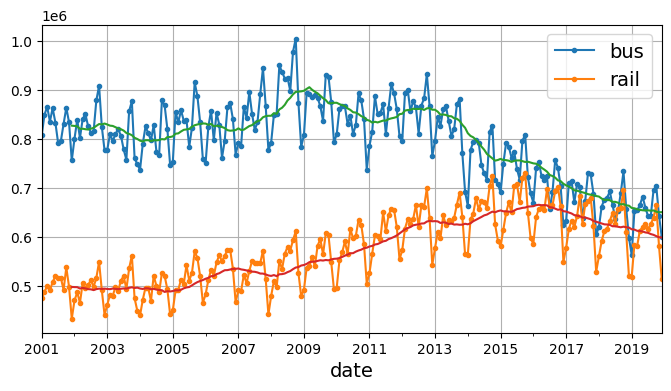

In [67]:
period = slice("2001", "2019")
df_monthly = df.resample('ME').mean(numeric_only=True) # compute the mean for each month, only for numeric columns
rolling_average_12_months = df_monthly[period].rolling(window=12).mean()
fig, ax = plt.subplots(figsize=(8, 4))
df_monthly[period].plot(ax=ax, marker=".")
rolling_average_12_months.plot(ax=ax, grid=True,legend=False)
plt.show()

In [68]:
print(df_monthly.index.min(), df_monthly.index.max())
print(df_monthly.loc[period].shape)


2001-01-31 00:00:00 2021-11-30 00:00:00
(228, 2)


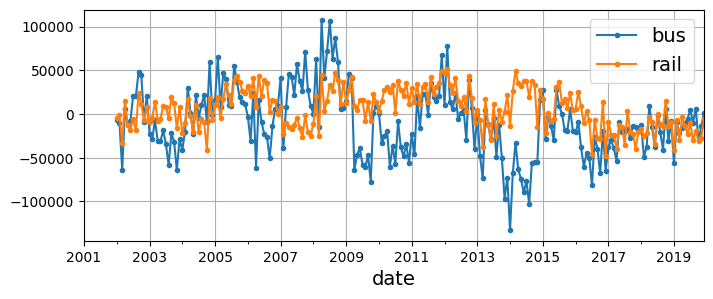

In [69]:
df_monthly.diff(12)[period].plot(grid=True, marker=".", figsize=(8, 3))
save_fig("yearly_diff_plot")  # extra code – saves the figure for the book
plt.show()

If running on Colab or Kaggle, install the statsmodels library:

In [70]:
if "google.colab" in sys.modules:
    %pip install -q -U statsmodels